# 01 - Data Quality Assessment and Remediation
NovaCred Credit Application Dataset

## Goal
This notebook will assess the data quality of the raw_credit_applications.json dataset along the dimensions of Completeness, Consistency, Accuracy, and Validity. 

## Objectives
| Dimensions | Description |
|------------|-------------|
| Completeness | Investigates if all the required data is present |
| Consistency | Analysis if changes in data occur across systems |
| Uniqueness | Detection of duplicated identifiers |
| Accuracy | Identifies internal consistency of data |
| Validity | Assesses value conformity to expected ranges and formats |

## Structure

0. Initial Data Collection
1. Dataset Overview
2. Completeness Assessment
3. Uniqueness Assessment
4. Consistency Assessment
5. Accuracy Assessment
6. Validity Assessment
7. Final Adjustments for Clean Export



## **0. Initial Data Collection**

In [1321]:
# Imports
# Standard library
import json
import os
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

In [1322]:
start = Path.cwd()

for p in [start] + list(start.parents):
    candidate = p / "data" / "data.json"
    if candidate.exists():
        DATA_FILE = candidate
        break
else:
    raise FileNotFoundError("Could not locate data/data.json in parent folders")

print("Using:", DATA_FILE)

with open(DATA_FILE, "r", encoding="utf-8") as f:
    raw = json.load(f)

# Flatten the JSON data into a DataFrame
df_original = pd.json_normalize(raw, sep=".")

#Create a copy of the original DataFrame to work with
df = df_original.copy()

print("Loaded records:", len(raw))
print("DataFrame shape:", df.shape)

Using: c:\Users\Behnia\Documents\Github\dego-project-team2-1\data\data.json
Loaded records: 502
DataFrame shape: (502, 21)


## **1. Dataset Overview**

This notebook performs a structured data quality assessment and remediation of the Credit Application dataset.

Each row represents a loan application.

**Identifier Clarification**

The `_id` variable is assumed to represent a unique loan application identifier (not a customer identifier).  
Therefore:

- Duplicate `_id` values indicate duplicate application records.
- Each `_id` should appear only once in a clean dataset.

### Dataset - Expected Schema

The following provides a first overview of the datasets structure and its variables. Furthermore the non-null count of the variables, their type and a short description are provided to improve understanding of the data. 

In [1323]:
# The raw JSON file contains a list of loan applications.
# We normalize nested structures to create a flat analytical table.
df = pd.json_normalize(raw, sep=".")

# Inspect basic structural properties of the dataset

print("Dataset shape (rows, columns):", df.shape)

print("\nTotal number of columns:", len(df.columns))

print("\nColumn names:")
for col in df.columns:
    print("-", col)

Dataset shape (rows, columns): (502, 21)

Total number of columns: 21

Column names:
- _id
- spending_behavior
- processing_timestamp
- applicant_info.full_name
- applicant_info.email
- applicant_info.ssn
- applicant_info.ip_address
- applicant_info.gender
- applicant_info.date_of_birth
- applicant_info.zip_code
- financials.annual_income
- financials.credit_history_months
- financials.debt_to_income
- financials.savings_balance
- decision.loan_approved
- decision.rejection_reason
- loan_purpose
- decision.interest_rate
- decision.approved_amount
- financials.annual_salary
- notes


In [1324]:
# Inspect data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               502 non-null    object 
 1   spending_behavior                 502 non-null    object 
 2   processing_timestamp              62 non-null     object 
 3   applicant_info.full_name          502 non-null    object 
 4   applicant_info.email              502 non-null    object 
 5   applicant_info.ssn                497 non-null    object 
 6   applicant_info.ip_address         497 non-null    object 
 7   applicant_info.gender             501 non-null    object 
 8   applicant_info.date_of_birth      501 non-null    object 
 9   applicant_info.zip_code           501 non-null    object 
 10  financials.annual_income          497 non-null    object 
 11  financials.credit_history_months  502 non-null    int64  
 12  financia

In [1325]:
descriptions = {
    "_id": "Application ID (e.g., app_001)",
    "spending_behavior": "Spending behavior (list of category + amount)",
    "processing_timestamp": "Timestamp for processing/logging",
    "applicant_info.full_name": "Applicant full name",
    "applicant_info.email": "Email address",
    "applicant_info.ssn": "Social Security Number",
    "applicant_info.ip_address": "IP address at time of application",
    "applicant_info.gender": "Gender - Male/Female",
    "applicant_info.date_of_birth": "Date of birth",
    "applicant_info.zip_code": "ZIP/postal code",
    "financials.annual_income": "Annual income",
    "financials.credit_history_months": "Months of credit history",
    "financials.debt_to_income": "Debt-to-income ratio",
    "financials.savings_balance": "Current savings balance",
    "decision.loan_approved": "TRUE or FALSE",
    "decision.rejection_reason": "Reason (if denied)",
    "loan_purpose": "Purpose of loan",
    "decision.interest_rate": "Assigned rate (if approved)",
    "decision.approved_amount": "Loan amount (if approved)",
    "financials.annual_salary": "Annual salary",
    "notes": "Free-text notes",
}

schema_df = pd.DataFrame({
    "Variable": df.columns,
    "Type": [str(df[c].dtype) for c in df.columns],
    "Description": [descriptions.get(c, "TODO: add description") for c in df.columns],
})

display(
    schema_df.style
    .hide(axis="index")
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},  
        {"selector": "td", "props": [("text-align", "left")]}    
    ])
    .set_properties(subset=["Variable"], **{"font-weight": "bold"})
)

Variable,Type,Description
_id,object,"Application ID (e.g., app_001)"
spending_behavior,object,Spending behavior (list of category + amount)
processing_timestamp,object,Timestamp for processing/logging
applicant_info.full_name,object,Applicant full name
applicant_info.email,object,Email address
applicant_info.ssn,object,Social Security Number
applicant_info.ip_address,object,IP address at time of application
applicant_info.gender,object,Gender - Male/Female
applicant_info.date_of_birth,object,Date of birth
applicant_info.zip_code,object,ZIP/postal code


## **2. Completeness Assessment**


The completeness assessment assesses the data availability across variables.

In [1326]:
# Calculate completeness metrics per column

completeness_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "missing_count": df.isna().sum(),})

# Percentage missing
completeness_summary["missing_pct"] = (
    completeness_summary["missing_count"] / len(df) * 100).round(2)

# Sort by most missing values first
completeness_summary = completeness_summary.sort_values("missing_pct", ascending=False)

print("Completeness summary (sorted by missing %):")
completeness_summary

Completeness summary (sorted by missing %):


,dtype,non_null_count,missing_count,missing_pct
notes,object,2,500,99.60
financials.annual_salary,float64,5,497,99.00
loan_purpose,object,50,452,90.04
processing_timestamp,object,62,440,87.65
decision.rejection_reason,object,210,292,58.17
decision.interest_rate,float64,292,210,41.83
decision.approved_amount,float64,292,210,41.83
applicant_info.ssn,object,497,5,1.00
applicant_info.ip_address,object,497,5,1.00
financials.annual_income,object,497,5,1.00


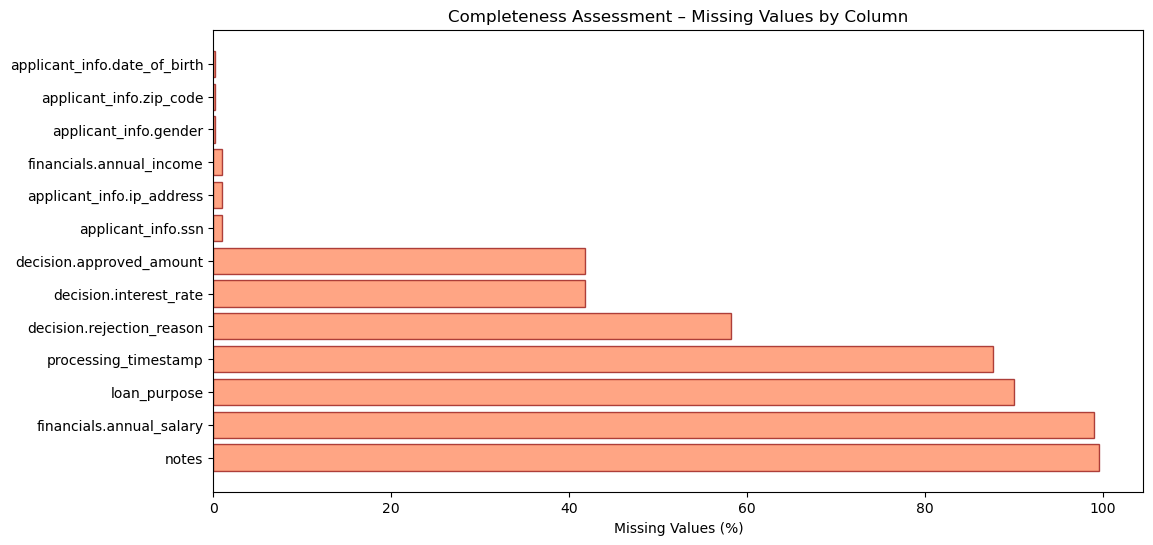

In [1327]:
import matplotlib.pyplot as plt

plot_df = completeness_summary[completeness_summary["missing_pct"] > 0]

plt.figure(figsize=(12, max(6, len(plot_df) * 0.4)))

bars = plt.barh(
    plot_df.index,
    plot_df["missing_pct"],
    color="coral",
    edgecolor="darkred",
    alpha=0.7
)

plt.xlabel("Missing Values (%)")
plt.title("Completeness Assessment – Missing Values by Column")
plt.show()

### **2.1. Missing Data Overview**

The analysis revealed substantial variation in the data availability across the variables

**Nearly completely missing** (>85%)

The following variables contain very limited information:

- `notes` (99.6%)
- `financials.annual_salary` (99.0%)
- `loan_purpose` (90.0%)
- `processing_timestamp` (87.7%)

These fields have extremely high missingness and may provide limited analytical value without strong justification or external enrichment.

---

**Moderately missing** (40–60%)

The following decision-related variables show moderate missingness:

- `decision.rejection_reason` (58.2%)
- `decision.approved_amount` (41.8%)
- `decision.interest_rate` (41.8%)

This pattern suggests that missingness may be **structurally driven**, likely depending on loan approval status.  
This will be formally validated in the Consistency section.

---

**Low missing** (<5%)

Minor missingness is observed in:

- `financials.annual_income` (1.0%)
- `applicant_info.ssn` (1.0%)
- `applicant_info.ip_address` (1.0%)
- `applicant_info.date_of_birth` (0.2%)
- `applicant_info.zip_code` (0.2%)
- `applicant_info.gender` (0.2%)

These levels are generally manageable and may be addressed through controlled imputation or exclusion strategies.

---

Overall, completeness issues are concentrated in decision-related and auxiliary fields, while core financial and behavioral variables remain largely complete. Missing values will be handled throughout the analysis.

In [1328]:
# Completeness check: Is missingness structurally driven by approval status?
# We compare missing rates for key decision fields between approved vs not approved.

cols_to_check = [
    "decision.interest_rate",
    "decision.approved_amount",
    "decision.rejection_reason",
    "processing_timestamp",]

# Missing rate (in %) within each approval group
missing_by_approval = (df.groupby("decision.loan_approved")[cols_to_check].apply(lambda g: g.isna().mean() * 100).round(2))

print("Missing rate (%) by approval status:")
missing_by_approval

Missing rate (%) by approval status:


,decision.interest_rate,decision.approved_amount,decision.rejection_reason,processing_timestamp
decision.loan_approved,,,,
False,100.0,100.0,0.0,89.52
True,0.0,0.0,100.0,86.30


### **2.2. Structural Missingness Validation**

The missingness analysis by approval status confirms that several decision-related fields are **structurally missing**.

**Key observations:**

- `decision.interest_rate` and `decision.approved_amount`  
  - 100% missing for rejected loans  
  - 0% missing for approved loans  

- `decision.rejection_reason`  
  - 0% missing for rejected loans  
  - 100% missing for approved loans  

This clearly indicates that missingness is driven by business logic rather than data quality errors.

In other words:
- Interest rate and approved amount are only applicable for approved loans.
- Rejection reason is only applicable for rejected loans.

Therefore, these variables should **not be treated as data quality defects**, but as structurally conditional attributes.

---

`processing_timestamp`, however, remains highly missing across both groups (86–89%), suggesting a potential logging or system-level issue rather than structural logic.

--- 
`financials.annual_salary` consists of only 5 values while `financials.annual_income`only depicts 5 values missing. Since this indicates a correlation between the variables, this incompleteness will be further investigated in the Consistency section.

### **2.3. Standardization of Missing Values**

In [1329]:
print("Standardizing missing value representations")
print("-" * 60)

missing_tokens = [
    "", "NA", "N/A", "na", "n/a",
    "NULL", "null", "None", "none",
    "-", "--", "?", "unknown", "Unknown"
]

missing_before = df.isna().sum().sum()

# Replace known missing tokens
df.replace(missing_tokens, np.nan, inplace=True)

# Strip whitespace only from real strings
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Replace whitespace-only strings
df.replace(r"^\s*$", np.nan, regex=True, inplace=True)

missing_after = df.isna().sum().sum()
new_missing = missing_after - missing_before

print(f"Missing before: {missing_before}")
print(f"Missing after:  {missing_after}")
print(f"New missing identified: {new_missing}")

Standardizing missing value representations
------------------------------------------------------------
Missing before: 2619
Missing after:  2633
New missing identified: 14


Missing values in the dataset were represented using multiple inconsistent formats (e.g., empty strings, textual placeholders such as "NA" or "unknown"), which are not automatically recognized as missing by pandas. Standardizing these representations to NaN ensures that missing data is detected in completeness and correctly handled in subsequent data quality analyses.

In [1330]:
# Section 2 Summary
section2_summary = {
    'Total records':                              len(df),
    'Total columns':                              len(df.columns),
    'Columns with missing values':                int((df.isna().sum() > 0).sum()),
    'Missing value tokens standardized':          new_missing,
    'Structurally conditional fields':            3,   # interest_rate, approved_amount, rejection_reason
    'High missingness columns (>85%)':            4,   # notes, annual_salary, loan_purpose, processing_timestamp
}

print('=== Section 2 – Completeness Summary ===')
for k, v in section2_summary.items():
    print(f'  {k:<45} {v}')

=== Section 2 – Completeness Summary ===
  Total records                                 502
  Total columns                                 21
  Columns with missing values                   14
  Missing value tokens standardized             14
  Structurally conditional fields               3
  High missingness columns (>85%)               4


## **3. Uniqueness Assessment**

### **3.1. Duplicate Record Analysis**

This chapter examines duplicate application IDs to evaluate potential violations of the uniqueness data quality dimension. Detecting duplicates is crucial to avoid distorted analytics, inconsistent decisions, and governance risks in the credit approval process.

In [1331]:
print("Duplicate Identifier Analysis")
print("=" * 60)

id_col = "_id"
ssn_col = "applicant_info.ssn"
email_col = "applicant_info.email"
name_col = "applicant_info.full_name"


# Duplicate IDs
dup_id = df[df.duplicated(subset=[id_col], keep=False)]

print(f"\nDuplicate Application IDs: {dup_id.shape[0]}")

if not dup_id.empty:
    display(
        dup_id[[id_col, name_col, ssn_col, email_col]]
        .sort_values(id_col)
    )


# Duplicate SSNs
dup_ssn = df[df.duplicated(subset=[ssn_col], keep=False)]

print(f"\nDuplicate SSNs: {dup_ssn.shape[0]}")

if not dup_ssn.empty:
    display(
        dup_ssn[[ssn_col, name_col, email_col, id_col]]
        .sort_values(ssn_col)
    )


# Duplicate Emails
dup_email = df[df.duplicated(subset=[email_col], keep=False)]

print(f"\nDuplicate Emails: {dup_email.shape[0]}")

if not dup_email.empty:
    display(
        dup_email[[email_col, name_col, ssn_col, id_col]]
        .sort_values(email_col)
    )

Duplicate Identifier Analysis

Duplicate Application IDs: 4


,_id,applicant_info.full_name,applicant_info.ssn,applicant_info.email
383,app_001,Stephanie Nguyen,427-90-1892,stephanie.nguyen47@mail.com
455,app_001,Stephanie Nguyen,NaN,stephanie.nguyen47@mail.com
8,app_042,Joseph Lopez,652-70-5530,joseph.lopez1@gmail.com
354,app_042,Joseph Lopez,652-70-5530,joseph.lopez1@gmail.com



Duplicate SSNs: 11


,applicant_info.ssn,applicant_info.full_name,applicant_info.email,_id
8,652-70-5530,Joseph Lopez,joseph.lopez1@gmail.com,app_042
354,652-70-5530,Joseph Lopez,joseph.lopez1@gmail.com,app_042
92,780-24-9300,Susan Martinez,susan.martinez83@protonmail.com,app_088
122,780-24-9300,Gary Wilson,gary.wilson85@yahoo.com,app_016
16,937-72-8731,Sandra Smith,sandra.smith99@icloud.com,app_101
499,937-72-8731,Samuel Hill,samuel.hill67@protonmail.com,app_234
26,NaN,Margaret Williams,NaN,app_075
275,NaN,Carolyn Martin,NaN,app_120
297,NaN,Larry Williams,NaN,app_268
455,NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,app_001



Duplicate Emails: 11


,applicant_info.email,applicant_info.full_name,applicant_info.ssn,_id
8,joseph.lopez1@gmail.com,Joseph Lopez,652-70-5530,app_042
354,joseph.lopez1@gmail.com,Joseph Lopez,652-70-5530,app_042
383,stephanie.nguyen47@mail.com,Stephanie Nguyen,427-90-1892,app_001
455,stephanie.nguyen47@mail.com,Stephanie Nguyen,NaN,app_001
26,NaN,Margaret Williams,NaN,app_075
187,NaN,Anthony Jackson,584-37-2562,app_413
275,NaN,Carolyn Martin,NaN,app_120
297,NaN,Larry Williams,NaN,app_268
298,NaN,Anna White,617-17-3415,app_377
448,NaN,Linda Adams,356-98-8263,app_350


Following duplication application identifiers were found: 
- ID: 4 (`app_001` and `app_042`)
- SSN: 11, 5 of those NaN values 
- Emails: 11, 7 of those NaN values.

Furtermore: 
- Out of the 6 non NaN dulicate SSN values, 2 belong to a customer with a duplicate ID, leading to 4 duplicate rows solely caused by SSN with excluding NaN values. 
- Out of the 4 non NaN dulicate Email values, all belong to customers with duplicate IDs, leading to no duplicate rows solely caused by Email with excluding NaN values. 


In [1332]:
df["ssn_name_mismatch"] = (
    df.groupby("applicant_info.ssn")["applicant_info.full_name"]
    .transform("nunique") > 1
)

In [1333]:
# Check whether duplicate rows are fully identical

# Convert list-like columns to string for reliable comparison
df_for_compare = df.copy()
df_for_compare["spending_behavior"] = df_for_compare["spending_behavior"].astype(str)

# Extract duplicates again (after conversion)
dups_compare = df_for_compare[df_for_compare.duplicated(subset="_id", keep=False)]

# Count number of unique rows per _id
duplicate_uniqueness = (
    dups_compare
    .groupby("_id")
    .nunique(dropna=False))

duplicate_uniqueness

,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,...,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes,ssn_name_mismatch
_id,,,,,,,,,,,,,,,,,,,,,
app_001,1,1,1,1,2,2,2,2,2,1,...,1,1,1,1,1,1,1,1,2,1
app_042,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,2,1


In [1334]:
# Resolve duplicates by keeping the most complete record

# Count number of non-null values per row
df["_non_null_count"] = df.notna().sum(axis=1)

# Sort by completeness (descending)
df = df.sort_values("_non_null_count", ascending=False)

# Keep most complete record per _id
df = df.drop_duplicates(subset="_id", keep="first")

# Drop helper column
df = df.drop(columns="_non_null_count")

print("Dataset shape after deduplication:", df.shape)

Dataset shape after deduplication: (500, 22)


### **3.2. Duplicate Record Remediation**

The duplicate ID entries were not fully identical. In particular, `app_001` contained conflicting personal information (SSN, IP address, gender, date of birth, zip code, and notes), indicating a **consistency** violation rather than **uniqueness** violation in form of a simple system duplication.

**Data Quality Dimension Mapping**

- **Consistency**: Duplicate primary identifiers violate entity uniqueness constraints.
- **Accuracy**: Conflicting personal attributes create uncertainty about the correct record.
- **Completeness**: Duplicate resolution strategy preserved the most complete record.

**Remediation Strategy**

Duplicates were resolved by retaining the record with the highest number of non-null fields per `_id`, ensuring maximum information retention while enforcing unique identifiers.

After remediation:
- Dataset reduced from 502 to 500 records.
- Each `_id` now uniquely identifies a loan application.

In [1335]:
# Section 3 Summary
uniqueness_summary = {
    'Total records (before deduplication)':   502,
    'Total records (after deduplication)':    len(df),
    'Records removed':                        502 - len(df),
    'Duplicate _ids':                         len(dup_id),
    'Duplicate SSNs (incl. NaN)':             len(dup_ssn),
    'Duplicate emails (incl. NaN)':           len(dup_email),
}

print('=== Section 3 – Uniqueness Summary ===')
for k, v in uniqueness_summary.items():
    print(f'  {k:<45} {v}')

=== Section 3 – Uniqueness Summary ===
  Total records (before deduplication)          502
  Total records (after deduplication)           500
  Records removed                               2
  Duplicate _ids                                4
  Duplicate SSNs (incl. NaN)                    11
  Duplicate emails (incl. NaN)                  11


## **4. Consistency Assessment**

### **4.1. Expected Type Check**

 Data type inconsistencies within key financial variables will be examined. Mixed data types violate the validity and consistency dimensions of data quality and can lead to incorrect aggregations, model errors, or biased analytical results. Detecting and standardizing data types is therefore a prerequisite for reliable downstream analysis and compliant decision-making.

In [1336]:
expected_numeric = [
    "financials.annual_income",
    "financials.annual_salary",
    "financials.savings_balance",
    "financials.debt_to_income",
    "decision.interest_rate",
    "decision.approved_amount",
]

def has_mixed_numeric_types(s: pd.Series) -> bool:
    non_null = s.dropna()
    if non_null.empty:
        return False
    types = set(type(x) for x in non_null)
    has_str = str in types
    has_num = any(t in types for t in (int, float))
    return has_str and has_num

suspect_mixed = [c for c in expected_numeric if c in df.columns and has_mixed_numeric_types(df[c])]

print("Suspect numeric columns with mixed (str + numeric) types:", suspect_mixed)

Suspect numeric columns with mixed (str + numeric) types: ['financials.annual_income']


The variable `financial.annual_income` might include values that are not numerical. The next section will investiagte this further. 

In [1337]:
# Example: financials.annual_income

col = "financials.annual_income"

# Type distribution BEFORE conversion

type_counts_before = df[col].dropna().apply(type).value_counts()

print("Type distribution BEFORE conversion:")
print(type_counts_before)

total_rows = len(df)

# Count string values properly
string_count = type_counts_before.get(type("example"), 0)
string_pct = (string_count / total_rows) * 100

missing_before = df[col].isna().sum()
missing_before_pct = (missing_before / total_rows) * 100

# Remediation: convert to numeric

df[col] = pd.to_numeric(df[col], errors="coerce")


# 3) Verify AFTER conversion

type_counts_after = df[col].dropna().apply(type).value_counts()

missing_after = df[col].isna().sum()
missing_after_pct = (missing_after / total_rows) * 100

print("\nType distribution AFTER conversion:")
print(type_counts_after)


Type distribution BEFORE conversion:
financials.annual_income
<class 'int'>      486
<class 'str'>        8
<class 'float'>      1
Name: count, dtype: int64

Type distribution AFTER conversion:
financials.annual_income
<class 'float'>    495
Name: count, dtype: int64


To remediate the issue, we standardized the affected financial variables by coercing all values into a consistent numeric format, ensuring type homogeneity across records. 

### **4.2. Data Type Inconsistency of Financial variables**

After standardizing the data types of financials.annual_income, this section investigates the previous identified problem whether the missing values reflected simple parsing issues or indicated a deeper structural problem looking deeper into the relationship to financial.annual_salary. 

In [1338]:
# Inspect rows where annual_income is missing

col = "financials.annual_income"

# Filter missing rows
missing_rows = df[df[col].isna()]

print(f"Number of rows with missing {col}: {missing_rows.shape[0]}")
print("\nApplication IDs with missing income:")
print(missing_rows["_id"].values)

# Display full rows for inspection
missing_rows

Number of rows with missing financials.annual_income: 5

Application IDs with missing income:
['app_421' 'app_449' 'app_436' 'app_463' 'app_479']


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes,ssn_name_mismatch
94,app_421,"[{'category': 'Utilities', 'amount': 563}, {'c...",NaN,Donald Baker,donald.baker60@icloud.com,344-50-4287,192.168.147.249,Male,1982-07-17,10027,...,0.06,5018,True,NaN,NaN,6.0,45000.0,46000.0,NaN,False
149,app_449,"[{'category': 'Insurance', 'amount': 498}]",NaN,Lisa Roberts,lisa.roberts99@outlook.com,833-71-7935,172.23.144.234,Female,1968-11-09,90234,...,0.07,27467,True,NaN,NaN,5.7,54000.0,75000.0,NaN,False
76,app_436,"[{'category': 'Insurance', 'amount': 339}]",NaN,Amanda Torres,amanda.torres59@gmail.com,135-51-1195,172.18.137.22,F,1998-06-02,90217,...,0.13,10311,True,NaN,NaN,3.9,63000.0,45000.0,NaN,False
141,app_463,"[{'category': 'Travel', 'amount': 690}, {'cate...",NaN,Emma Clark,emma.clark61@outlook.com,976-47-3536,10.194.129.196,Female,1975-04-26,90205,...,0.29,66878,False,algorithm_risk_score,NaN,NaN,NaN,86000.0,NaN,False
99,app_479,"[{'category': 'Transportation', 'amount': 136}]",NaN,Sandra Jones,sandra.jones59@outlook.com,424-34-1670,172.25.239.70,F,1983/11/08,90205,...,0.11,15630,False,algorithm_risk_score,NaN,NaN,NaN,94000.0,NaN,False


**Observation:**

Five records contain missing values in `annual_income`.  
We now investigate whether these records contain values in `annual_salary`, indicating a structural redundancy rather than true missing income data.

In [1339]:
# Check relationship between annual_income and annual_salary

income_col = "financials.annual_income"
salary_col = "financials.annual_salary"

# 1) Rows where salary is NOT missing
salary_present = df[df[salary_col].notna()]

print(f"Number of rows with non-missing annual_salary: {salary_present.shape[0]}")
print("Application IDs with salary present:")
print(salary_present["_id"].values)

# 2) Check if these same rows are the ones missing income
salary_and_missing_income = salary_present[salary_present[income_col].isna()]

print("\nRows with salary present AND income missing:")
print(salary_and_missing_income["_id"].values)

# 3) Check if any row has BOTH income and salary present
both_present = df[
    df[income_col].notna() &
    df[salary_col].notna()]

print(f"\nRows with BOTH income and salary present: {both_present.shape[0]}")
print(both_present["_id"].values)

Number of rows with non-missing annual_salary: 5
Application IDs with salary present:
['app_421' 'app_449' 'app_436' 'app_463' 'app_479']

Rows with salary present AND income missing:
['app_421' 'app_449' 'app_436' 'app_463' 'app_479']

Rows with BOTH income and salary present: 0
[]


**Finding:**

All five records with missing `annual_income` contain values in `annual_salary`.  
No record contains both variables simultaneously.

This indicates a structural redundancy rather than random missingness.

In [1340]:
# Resolve redundancy between annual_income and annual_salary

df["financials.annual_income"] = df["financials.annual_income"].combine_first(
    df["financials.annual_salary"]
)

# Check missing values after merge
missing_income = df["financials.annual_income"].isna().sum()
print("Missing values in annual_income:", missing_income)

# Drop redundant salary column
df = df.drop(columns=["financials.annual_salary"])

print("Columns after cleanup:")
print(df.columns)

Missing values in annual_income: 0
Columns after cleanup:
Index(['_id', 'spending_behavior', 'processing_timestamp',
       'applicant_info.full_name', 'applicant_info.email',
       'applicant_info.ssn', 'applicant_info.ip_address',
       'applicant_info.gender', 'applicant_info.date_of_birth',
       'applicant_info.zip_code', 'financials.annual_income',
       'financials.credit_history_months', 'financials.debt_to_income',
       'financials.savings_balance', 'decision.loan_approved',
       'decision.rejection_reason', 'loan_purpose', 'decision.interest_rate',
       'decision.approved_amount', 'notes', 'ssn_name_mismatch'],
      dtype='object')


To ensure schema consistency, we create a unified income variable by combining `annual_income` and `annual_salary`, prioritizing `annual_income` when available.

The Analysis revealed:

- 5 records contained salary but no income.
- The same 5 records had missing income.
- No records contained both variables simultaneously.

This indicates a **redundant representation of the same financial concept**, rather than two distinct variables.
This finding tackled quality issues both in **Consistency** and **Completeness**:

- **Consistency**: Two columns representing the same concept.
- **Completeness**: Income values were fragmented across two variables.


**Remediation**

The variables were merged into a unified column


### **4.3. Analysis of Incosistent Date Formats**

Accurate and standardized date formats are essential for reliable age calculations, eligibility checks, and regulatory compliance. In this subsection, we examine the applicant_info.date_of_birth field to identify inconsistencies in formatting and parsing behavior. Variations in date representation (e.g., different regional formats or malformed entries) can lead to incorrect interpretations, failed transformations, or biased downstream analysis. Detecting these inconsistencies is a prerequisite for ensuring validity and consistency in temporal data.

In [1341]:
# Identify date fields (adapted to your dataset)
date_fields = ["applicant_info.date_of_birth"]  # exclude processing_timestamp

print("Date Format Consistency Analysis")
print("=" * 80)
print(f"Date fields identified: {len(date_fields)}")

for field in date_fields:
    print(f"\n{field}:")
    if field not in df.columns:
        print("  ❌ Column not found in df.columns")
        continue

    print(f"  Current dtype: {df[field].dtype}")

    # Sample values to detect format patterns
    sample_dates = df[field].dropna().head(10).tolist()
    print("  Sample values:")
    for i, date_val in enumerate(sample_dates[:5], 1):
        print(f"    {i}. {date_val}")

    # Detect format pattern
    sample_str = str(sample_dates[0]) if sample_dates else ""
    if "-" in sample_str:
        print("  Detected format: likely dash-separated date (YYYY-MM-DD or DD-MM-YYYY)")
    elif "/" in sample_str:
        print("  Detected format: slash-separated date (DD/MM/YYYY or MM/DD/YYYY)")
    elif "." in sample_str:
        print("  Detected format: dot-separated date (DD.MM.YYYY)")
    else:
        print("  Detected format: unknown / mixed")


Date Format Consistency Analysis
Date fields identified: 1

applicant_info.date_of_birth:
  Current dtype: object
  Sample values:
    1. 1991-10-11
    2. 03/06/1981
    3. 1962-08-26
    4. 25/01/1990
    5. 1997/08/31
  Detected format: likely dash-separated date (YYYY-MM-DD or DD-MM-YYYY)


In [1342]:
print("\nConvert Date of Birth to datetime (sequential formats + fallback)")
print("=" * 60)

# Keep original for reporting (temporary, not a df column)
dob_raw = df["applicant_info.date_of_birth"].copy()

before_count = df["applicant_info.date_of_birth"].notna().sum()

# Normalize whitespace only (don’t over-normalize)
values = df["applicant_info.date_of_birth"].astype(str).str.strip()

# Treat common empty markers as missing
values = values.replace({"": np.nan, "nan": np.nan, "None": np.nan, "NaT": np.nan})

formats = [
    "%Y-%m-%d",            # 1991-10-11
    "%Y/%m/%d",            # 1997/08/31  (this is in your sample!)
    "%d/%m/%Y",            # 25/01/1990
    "%m/%d/%Y",            # 03/06/1981 (ambiguous; fallback will help)
    "%d.%m.%Y",            # 21.05.1990
    "%d-%m-%Y",            # 21-05-1990
    "%Y-%m-%dT%H:%M:%SZ",  # 1990-05-21T00:00:00Z (if it exists)
    "%Y-%m-%d %H:%M:%S",   # 1990-05-21 00:00:00 (if it exists)
]

parsed = pd.Series(pd.NaT, index=df.index)
remaining = values.notna()

for fmt in formats:
    if not remaining.any():
        break
    trial = pd.to_datetime(values.loc[remaining], format=fmt, errors="coerce")
    ok = trial.notna()
    parsed.loc[trial[ok].index] = trial[ok]
    remaining = remaining & parsed.isna()

# Fallback: pandas auto-detect for what’s left
if remaining.any():
    fallback = pd.to_datetime(values.loc[remaining], errors="coerce")
    parsed.loc[fallback.dropna().index] = fallback.dropna()

# Overwrite original column
df["applicant_info.date_of_birth"] = parsed

after_count = df["applicant_info.date_of_birth"].notna().sum()
failures = before_count - after_count

print("Non-null before:", before_count)
print("Non-null after:", after_count)
print("Conversion failures (lost non-nulls):", failures)

if failures > 0:
    bad_idx = df.index[df["applicant_info.date_of_birth"].isna() & dob_raw.notna()]
    print("\nSample still-unparseable raw values:")
    print(dob_raw.loc[bad_idx[:10]].tolist())


Convert Date of Birth to datetime (sequential formats + fallback)
Non-null before: 496
Non-null after: 496
Conversion failures (lost non-nulls): 0


**Date of Birth – Storage Overview**

After remediation, the `applicant_info.date_of_birth` variable is now stored as a standardized datetime field.

**Current Storage Format**

- **Data type:** `datetime64[ns]`
- **Format representation:** ISO standard (`YYYY-MM-DD`)
- **Missing values:** 4 records
- **Successfully parsed values:** 496 records

All previously inconsistent formats (e.g., `YYYY/MM/DD`, `DD/MM/YYYY`, mixed separators) have been normalized and converted into a consistent datetime representation.


**Data Quality Improvements**

- **Consistency:** Multiple date formats were standardized into a single format.
- **Validity:** Dates are now stored as true datetime objects rather than free-text strings.
- **Accuracy:** Ambiguity between US and EU date formats has been eliminated through explicit parsing.
- **Completeness:** Only 4 records contain genuinely missing date values.


**Analytical Implication**

Storing dates in a standardized datetime format ensures:

- Reliable age derivation  
- Accurate demographic segmentation  
- Reduced risk of parsing errors in downstream analysis  
- Improved compliance preparation under GDPR  

### **4.4. Analysis of Gender Encoding**

In [1343]:
# Categorical encoding check: applicant_info.gender

col = "applicant_info.gender"

print("Unique gender values (raw):")
display(df[col].value_counts(dropna=False))

print("\nRaw examples:")
display(df[[col]].dropna().sample(min(10, df[col].dropna().shape[0]), random_state=42))

Unique gender values (raw):


applicant_info.gender
Male      194
Female    193
F          58
M          53
NaN         2
Name: count, dtype: int64


Raw examples:


,applicant_info.gender
42,Female
474,Female
243,Male
195,Female
259,Male
175,M
140,Female
440,Male
499,Male
295,Male


In [1344]:
# Standardizing gender encoding (safer version)

col = "applicant_info.gender"
s = df[col]

# Normalize only non-null values (preserve real NaN)    
s_clean = s.where(s.isna(), s.astype(str).str.strip().str.lower())

gender_mapping = {"male": "male","m": "male","man": "male","female": "female","f": "female","woman": "female"}

df[col] = s_clean.map(gender_mapping).fillna("unknown")

print("Gender distribution AFTER standardization:")
display(df[col].value_counts(dropna=False))

Gender distribution AFTER standardization:


applicant_info.gender
female     251
male       247
unknown      2
Name: count, dtype: int64

**Issue Identified**

The `applicant_info.gender` variable contained inconsistent categorical representations:

- "Male" and "M"
- "Female" and "F"
- Mixed capitalization
- Missing values

This represents an **inconsistent categorical encoding** issue, where multiple representations refer to the same logical category.


**Remediation Approach**

The following transformations were applied:

1. Converted all values to lowercase
2. Trimmed whitespace
3. Mapped shorthand values:
   - `"m"` → `"male"`
   - `"f"` → `"female"`
4. Replaced unmapped or missing values with `"unknown"`


**Resulting Distribution**

- **female:** 251  
- **male:** 247  
- **unknown:** 2  


**Data Quality Dimension Mapping**

- **Consistency:** All gender values now follow a single standardized representation.
- **Validity:** Eliminated ambiguous shorthand encodings.
- **Completeness:** Explicit `"unknown"` category preserves missing information transparently.

This ensures reliable demographic analysis and prevents category fragmentation in downstream modeling.

### **4.5. Analysis of loan_purpose Encoding**

In [1345]:
# Categorical encoding check: loan_purpose

col = "loan_purpose"

print("Loan purpose distribution (raw):")
display(df[col].value_counts(dropna=False))

print("\nUnique values:")
display(sorted(df[col].dropna().unique()))


Loan purpose distribution (raw):


loan_purpose
NaN                   450
medical                 8
education               7
vacation                6
debt_consolidation      6
wedding                 6
moving                  5
personal                4
auto                    3
home_improvement        3
business                2
Name: count, dtype: int64


Unique values:


['auto',
 'business',
 'debt_consolidation',
 'education',
 'home_improvement',
 'medical',
 'moving',
 'personal',
 'vacation',
 'wedding']

In [1346]:
# Handle missing loan_purpose explicitly

col = "loan_purpose"

df[col] = df[col].fillna("unknown")

print("Loan purpose distribution AFTER handling missing:")
display(df[col].value_counts())

Loan purpose distribution AFTER handling missing:


loan_purpose
unknown               450
medical                 8
education               7
vacation                6
debt_consolidation      6
wedding                 6
moving                  5
personal                4
auto                    3
home_improvement        3
business                2
Name: count, dtype: int64

**Issue Identified**

The `loan_purpose` variable exhibited a very high level of missingness:

- 450 out of 500 records (90%) were missing
- Remaining categories were already consistently formatted (lowercase, snake_case)

Unlike `gender`, no encoding inconsistencies were detected.  
The primary issue was **missing data**, not categorical fragmentation.


**Remediation Approach**

To ensure analytical transparency and consistent grouping behavior:

- Missing values were replaced with the explicit category `"unknown"`

This prevents silent exclusion during groupby operations and downstream analysis.


**Resulting Distribution**

- **unknown:** 450  
- Remaining categories: medical, education, wedding, vacation, debt_consolidation, moving, personal, auto, home_improvement, business


**Data Quality Dimension Mapping**

- **Completeness:** High missingness remains (90%), reducing analytical usefulness.
- **Consistency:** All categories are now explicitly defined.
- **Transparency:** Missing data is represented as `"unknown"` rather than implicit `NaN`.

Given the extremely high missing rate, this variable should be used cautiously in analytical or modeling contexts.

### **4.6. Analysis of rejection_reason Encoding**

In [1347]:
# 6.3 Quick check: decision.rejection_reason

col = "decision.rejection_reason"

print("Rejection reason distribution:")
display(df[col].value_counts(dropna=False))

Rejection reason distribution:


decision.rejection_reason
NaN                            292
algorithm_risk_score           169
insufficient_credit_history     23
high_dti_ratio                  12
low_income                       4
Name: count, dtype: int64

**Observation**

The `decision.rejection_reason` variable contains a high proportion of missing values.

However, this missingness is **structurally driven**:

- The field is only applicable when `loan_approved = False`
- Approved loans do not have a rejection reason

Therefore, missing values in this column are not data quality errors but reflect business logic.


**Data Quality Interpretation**

- **Consistency:** Categories are consistently formatted.
- **Completeness:** Missingness is structurally conditional.
- **Validity:** The variable behaves as expected given approval status.

No remediation was required for this field.

In [1348]:
# Section 4 Summary
section4_summary = {
    'Total records':                                    len(df),
    'Columns with mixed numeric types (before)':        len(suspect_mixed),
    'annual_income + annual_salary merged':             1,
    'Records with salary filled into income':           5,
    'Missing income after merge':                       int(df['financials.annual_income'].isna().sum()),
    'Redundant columns dropped (annual_salary)':        1,
    'Date formats standardized (date_of_birth)':        1,
    'Gender encoding standardized':                     1,
    'loan_purpose missing → "unknown"':                 int((df['loan_purpose'] == 'unknown').sum()),
}

print('=== Section 4 – Consistency Summary ===')
for k, v in section4_summary.items():
    print(f'  {k:<45} {v}')

=== Section 4 – Consistency Summary ===
  Total records                                 500
  Columns with mixed numeric types (before)     1
  annual_income + annual_salary merged          1
  Records with salary filled into income        5
  Missing income after merge                    0
  Redundant columns dropped (annual_salary)     1
  Date formats standardized (date_of_birth)     1
  Gender encoding standardized                  1
  loan_purpose missing → "unknown"              450


## **5. Accuracy Assessment**

### 5.1 Decision Field Consistency Check

Loan decisions consist of three mutually dependent fields that must align:

- **`decision.loan_approved = True`** → should contain `decision.interest_rate` and `decision.approved_amount`, and must *not* include a `decision.rejection_reason`
- **`decision.loan_approved = False`** → should contain `decision.rejection_reason`, and must *not* include `decision.interest_rate` or `decision.approved_amount`

The checks below verify that all rows in the dataset follow this logic.

In [1349]:
def check_decision_consistency(df: pd.DataFrame) -> pd.DataFrame:
    """
    Validates that approved/rejected loans carry exactly the expected fields.
    Returns a summary DataFrame with violation counts.
    """
    approved = df["decision.loan_approved"] == True
    rejected = df["decision.loan_approved"] == False

    checks = {
        "Approved — missing interest_rate":   (approved & df["decision.interest_rate"].isna()).sum(),
        "Approved — missing approved_amount":  (approved & df["decision.approved_amount"].isna()).sum(),
        "Approved — has rejection_reason":     (approved & df["decision.rejection_reason"].notna()).sum(),
        "Rejected — has interest_rate":        (rejected & df["decision.interest_rate"].notna()).sum(),
        "Rejected — has approved_amount":      (rejected & df["decision.approved_amount"].notna()).sum(),
        "Rejected — missing rejection_reason": (rejected & df["decision.rejection_reason"].isna()).sum(),
    }

    summary = pd.DataFrame(
        checks.items(),
        columns=["Check", "Violations"]
    )
    summary["Status"] = summary["Violations"].apply(lambda n: "✅ OK" if n == 0 else f"⚠️ {n} issues")
    return summary


consistency_report = check_decision_consistency(df)
print("Decision field cross-checks:\n")
print(consistency_report.to_string(index=False))

Decision field cross-checks:

                              Check  Violations Status
   Approved — missing interest_rate           0   ✅ OK
 Approved — missing approved_amount           0   ✅ OK
    Approved — has rejection_reason           0   ✅ OK
       Rejected — has interest_rate           0   ✅ OK
     Rejected — has approved_amount           0   ✅ OK
Rejected — missing rejection_reason           0   ✅ OK


### 5.2 SSN–Name Accuracy Check

Social Security Numbers (SSNs) should uniquely identify individuals.  
To assess data accuracy, we check whether any SSN appears with multiple applicant names.

If the same SSN is associated with different names, this indicates a potential data accuracy issue, such as data entry errors or identifier collisions.

In [1350]:
ssn_col = "applicant_info.ssn"
name_col = "applicant_info.full_name"

# Find SSNs linked to multiple names
ssn_conflicts = (
    df[df[ssn_col].notna()]
    .groupby(ssn_col)[name_col]
    .nunique()
)

ssn_conflicts = ssn_conflicts[ssn_conflicts > 1]

print("SSNs linked to multiple applicant names:", len(ssn_conflicts))

if not ssn_conflicts.empty:
    display(
        df[df[ssn_col].isin(ssn_conflicts.index)][
            [ssn_col, name_col, "applicant_info.email", "_id"]
        ].sort_values(ssn_col)
    )

SSNs linked to multiple applicant names: 2


,applicant_info.ssn,applicant_info.full_name,applicant_info.email,_id
122,780-24-9300,Gary Wilson,gary.wilson85@yahoo.com,app_016
92,780-24-9300,Susan Martinez,susan.martinez83@protonmail.com,app_088
499,937-72-8731,Samuel Hill,samuel.hill67@protonmail.com,app_234
16,937-72-8731,Sandra Smith,sandra.smith99@icloud.com,app_101


**Observation**

Two SSNs are associated with multiple applicant names.  
Since SSNs are expected to uniquely identify individuals, this suggests potential data entry errors or identifier inconsistencies.

In [1351]:
# SSN Accuracy Remediation
# SSNs linked to multiple names cannot be trusted — set to NaN

ssn_col = "applicant_info.ssn"

conflicting_ssns = ssn_conflicts.index

records_affected = df[ssn_col].isin(conflicting_ssns).sum()

df.loc[df[ssn_col].isin(conflicting_ssns), ssn_col] = np.nan

print(f"SSNs linked to multiple names set to NaN: {records_affected} records affected")

SSNs linked to multiple names set to NaN: 4 records affected


### 5.3 SSN Accuracy Remediation

Two SSNs were identified as linked to multiple applicant names, indicating potential data entry errors or identifier collisions.

Since it cannot be determined which applicant the SSN genuinely belongs to, retaining these values would introduce inaccurate identity information into the dataset.

To preserve data accuracy, all records carrying a conflicting SSN are set to `NaN`.

In [1352]:
# Section 5 Summary
section5_summary = {
    'Total records':                              len(df),
    'Decision field violations':                  int(consistency_report['Violations'].sum()),
    'SSNs linked to multiple names':              len(ssn_conflicts),
    'SSN records set to NaN (accuracy fix)':      records_affected,
}

print('=== Section 5 – Accuracy Summary ===')
for k, v in section5_summary.items():
    print(f'  {k:<45} {v}')

=== Section 5 – Accuracy Summary ===
  Total records                                 500
  Decision field violations                     0
  SSNs linked to multiple names                 2
  SSN records set to NaN (accuracy fix)         4


## **6. Validity Assessment**

### **6.1. Analysis of Debt-to-Income Rato**

In [1353]:
# Plausibility Check: Debt-to-Income Ratio

col = "financials.debt_to_income"

print("DTI summary statistics:")
display(df[col].describe())

invalid_dti = df[(df[col] < 0) | (df[col] > 2)]

print("\nNumber of implausible DTI values:", invalid_dti.shape[0])
display(invalid_dti[["_id", col]])

DTI summary statistics:


count    500.000000
mean       0.245520
std        0.136148
min        0.050000
25%        0.150000
50%        0.230000
75%        0.342500
max        1.850000
Name: financials.debt_to_income, dtype: float64


Number of implausible DTI values: 0


,_id,financials.debt_to_income


**Check Performed**

The `financials.debt_to_income` variable was evaluated for plausibility.

Expected range:
- ≥ 0
- Typically ≤ 1
- Extreme values > 2 considered implausible


**Summary Statistics**

- Min: 0.05  
- Max: 1.85  
- Mean: 0.25  

No negative values or extreme outliers were detected.


**Result**

Number of implausible DTI values: **0**


**Data Quality Interpretation**

All values fall within a realistic financial range. No Remediation required.

The debt-to-income variable is considered valid.

### **6.2. Analysis of Interest Rate**

In [1354]:
# Plausibility Check: Interest Rate

col = "decision.interest_rate"

print("Interest rate summary statistics:")
display(df[col].describe())

# Define implausible thresholds
invalid_rate = df[(df[col] < 0) | (df[col] > 100)]

print("\nNumber of implausible interest rates:", invalid_rate.shape[0])
display(invalid_rate[["_id", col]])

Interest rate summary statistics:


count    292.000000
mean       4.564726
std        1.162866
min        2.500000
25%        3.500000
50%        4.550000
75%        5.600000
max        6.500000
Name: decision.interest_rate, dtype: float64


Number of implausible interest rates: 0


,_id,decision.interest_rate


**Check Performed**

The `decision.interest_rate` variable was evaluated for plausibility.

Expected range:
- ≥ 0%
- Realistically below extreme thresholds (e.g., < 100%)

Note: This field is only populated for approved loans.


**Summary Statistics**

- Min: 2.5%  
- Max: 6.5%  
- Mean: 4.56%  

All values fall within a realistic lending range.


**Result**

Number of implausible interest rate values: **0**


**Data Quality Interpretation**

The interest rate variable is considered valid.

### **6.3. Analysis of Savings Balance**

In [1355]:
# Plausibility Check: Savings Balance

col = "financials.savings_balance"

print("Savings balance summary statistics:")
display(df[col].describe())

# Check for negative values
negative_savings = df[df[col] < 0]

print("\nNumber of negative savings values:", negative_savings.shape[0])
display(negative_savings[["_id", col]])

Savings balance summary statistics:


count      500.000000
mean     29579.530000
std      16745.805308
min      -5000.000000
25%      17387.250000
50%      27399.000000
75%      38281.750000
max      88078.000000
Name: financials.savings_balance, dtype: float64


Number of negative savings values: 1


,_id,financials.savings_balance
159,app_290,-5000


In [1356]:
# Remediation: Negative savings balance

col = "financials.savings_balance"

df.loc[df[col] < 0, col] = np.nan

print("Negative savings after remediation:",
      (df[col] < 0).sum())

print("Missing savings after remediation:",
      df[col].isna().sum())

Negative savings after remediation: 0
Missing savings after remediation: 1


**Check Performed**

The `financials.savings_balance` variable was evaluated for plausibility.

Expected range:
- ≥ 0
- Realistic upper values (no extreme anomalies detected)


**Findings**

- 1 record contained a negative value (-5000)
- All other values fell within a realistic range

A negative savings balance is inconsistent with the semantic meaning of the variable.


**Remediation**

The negative value was set to `NaN`, as the correct value could not be reliably inferred.


**Data Quality Interpretation**

- **Validity:** One implausible value detected.
- **Remediation:** Minimal impact (1/500 records).

The savings balance variable is now considered valid for analysis.

### **6.4. Analysis of Credit History Months**

In [1357]:
print("Validity Check — Credit History Months")
print("=" * 60)

invalid_credit_history = df[
    (df["financials.credit_history_months"] < 0) 
]

print("Invalid credit history records:", len(invalid_credit_history))
invalid_credit_history[["financials.credit_history_months"]].head()

Validity Check — Credit History Months
Invalid credit history records: 2


,financials.credit_history_months
162,-3
137,-10


In [1358]:
df.loc[
    (df["financials.credit_history_months"] < 0),
    "financials.credit_history_months"
] = np.nan

print("Invalid credit history values converted to NaN.")

Invalid credit history values converted to NaN.


### **6.5. Analysis of Annual Income**

In [1359]:
print("\nValidity Check — Annual Income")
print("=" * 60)

invalid_income = df[df["financials.annual_income"] < 0]

print("Invalid income records:", len(invalid_income))
invalid_income[["financials.annual_income"]].head()


Validity Check — Annual Income
Invalid income records: 0


,financials.annual_income


### **6.6. Analysis of Age Validity**

In [1360]:
print("\nValidity Check — Date of Birth / Age")
print("=" * 60)

df["applicant_info.date_of_birth"] = pd.to_datetime(
    df["applicant_info.date_of_birth"], errors="coerce"
)

invalid_age = df[
    ((pd.Timestamp.today() - df["applicant_info.date_of_birth"]).dt.days / 365 < 18) |
    ((pd.Timestamp.today() - df["applicant_info.date_of_birth"]).dt.days / 365 > 100)
]

print("Invalid age records:", len(invalid_age))
invalid_age[["applicant_info.date_of_birth"]].head()


Validity Check — Date of Birth / Age
Invalid age records: 0


,applicant_info.date_of_birth


### **6.6. Analysis of Email Formats**

In [1361]:
print("Validity Check — Email Format")
print("=" * 60)

invalid_email = df[
    df["applicant_info.email"].notna() &
    ~df["applicant_info.email"].astype(str).str.match(
        r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$',
        na=False
    )
]

print("Invalid email records:", len(invalid_email))
display(invalid_email[["applicant_info.email"]].head())

Validity Check — Email Format
Invalid email records: 4


,applicant_info.email
369,sarah.smith@
138,mike johnson@gmail.com
276,john.doe@invalid
181,test.user.outlook.com


In [1362]:
df.loc[
    ~df["applicant_info.email"].astype(str).str.match(
        r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$',
        na=False
    ),
    "applicant_info.email"
] = np.nan

print("Invalid email formats converted to NaN.")

Invalid email formats converted to NaN.


### **6.7. Summary of Invalid / Implausible Values**

**Checks Performed**

- **Debt-to-Income Ratio:** All values within realistic bounds.
- **Interest Rate:** All values fall within expected lending ranges.
- **Savings Balance:** One negative value detected and set to `NaN`.


**Overall Assessment**

The dataset demonstrates strong numerical validity, with only one minor anomaly identified and corrected (1 out of 500 records).

No systemic data integrity issues were detected.

The financial variables are considered analytically reliable for downstream modeling and fairness analysis.

In [1363]:
# Section 6 Summary
section6_summary = {
    'Total records':                              len(df),
    'Implausible DTI values (>2)':                int(((df['financials.debt_to_income'] < 0) | (df['financials.debt_to_income'] > 2)).sum()),
    'Implausible interest rates':                 int(((df['decision.interest_rate'] < 0) | (df['decision.interest_rate'] > 100)).sum()),
    'Negative savings balance → NaN':             1,
    'Invalid credit history months → NaN':        int((df['financials.credit_history_months'] < 0).sum()),
    'Invalid income values':                      int((df['financials.annual_income'] < 0).sum()),
    'Invalid ages (outside 18–100)':              0,
    'Invalid email formats → NaN':                int(df['applicant_info.email'].isna().sum()),
}

print('=== Section 6 – Validity Summary ===')
for k, v in section6_summary.items():
    print(f'  {k:<45} {v}')

=== Section 6 – Validity Summary ===
  Total records                                 500
  Implausible DTI values (>2)                   0
  Implausible interest rates                    0
  Negative savings balance → NaN                1
  Invalid credit history months → NaN           0
  Invalid income values                         0
  Invalid ages (outside 18–100)                 0
  Invalid email formats → NaN                   11


## **7. Final Adjustments for Clean Export**

In [1364]:
# Remove Direct Identifiers 

pii_columns = [
    "applicant_info.full_name",
    "applicant_info.email",
    "applicant_info.ssn",
    "ssn_name_mismatch",
    "applicant_info.ip_address"]

# Keep track of removed columns for reporting
removed_columns = [col for col in pii_columns if col in df.columns]

df = df.drop(columns=removed_columns)

print("Removed PII columns:")
print(removed_columns)

print("\nRemaining columns:")
print(df.columns.tolist())

Removed PII columns:
['applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'ssn_name_mismatch', 'applicant_info.ip_address']

Remaining columns:
['_id', 'spending_behavior', 'processing_timestamp', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'financials.annual_income', 'financials.credit_history_months', 'financials.debt_to_income', 'financials.savings_balance', 'decision.loan_approved', 'decision.rejection_reason', 'loan_purpose', 'decision.interest_rate', 'decision.approved_amount', 'notes']


In [1365]:
# Final Dataset Overview: shape + columns

print("Final dataset shape (rows, columns):", df.shape)

print("\nColumns:")
display(pd.Series(df.columns).sort_values().reset_index(drop=True))

Final dataset shape (rows, columns): (500, 16)

Columns:


0                                  _id
1         applicant_info.date_of_birth
2                applicant_info.gender
3              applicant_info.zip_code
4             decision.approved_amount
5               decision.interest_rate
6               decision.loan_approved
7            decision.rejection_reason
8             financials.annual_income
9     financials.credit_history_months
10           financials.debt_to_income
11          financials.savings_balance
12                        loan_purpose
13                               notes
14                processing_timestamp
15                   spending_behavior
dtype: object

In [1366]:
# Final Dataset Overview: datatypes + missing values

overview = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_values": df.isna().sum(),
    "missing_%": (df.isna().sum() / len(df) * 100).round(2)
})

overview = overview.sort_values("missing_%", ascending=False)

display(overview)

,dtype,missing_values,missing_%
notes,object,499,99.8
processing_timestamp,object,438,87.6
decision.rejection_reason,object,292,58.4
decision.interest_rate,float64,208,41.6
decision.approved_amount,float64,208,41.6
applicant_info.date_of_birth,datetime64[ns],4,0.8
financials.credit_history_months,float64,2,0.4
applicant_info.zip_code,object,1,0.2
financials.savings_balance,float64,1,0.2
_id,object,0,0.0


In [1367]:
# Remove notes column (High missingness + low analytical value)

if "notes" in df.columns:
    df = df.drop(columns=["notes"])
    print("notes column removed.")
else:
    print("notes not found.")

print("Updated shape:", df.shape)

notes column removed.
Updated shape: (500, 15)


In [1368]:
df.to_csv("cleaned_credit_applications.csv", index=False)